# 🔍 Exploratory Data Analysis — Telco Customer Churn

**Input:** `data/telco_churn_cleaned.csv`  
**Output:** Charts exported to `reports/figures/` — ready for Power BI / Tableau.

### 🗂️ Sections
1. Load data & setup
2. KPI Summary
3. Churn distribution
4. Demographics analysis
5. Account & contract analysis
6. Services analysis
7. Charges analysis
8. Tenure analysis
9. Correlation heatmap
10. Key takeaways

## 1️⃣ Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────
PALETTE   = {'No': '#6366f1', 'Yes': '#f43f5e'}   # indigo / rose
BG_COLOR  = '#0f172a'
TEXT_COLOR = '#e2e8f0'
ACCENT    = '#a855f7'

plt.rcParams.update({
    'figure.facecolor' : BG_COLOR,
    'axes.facecolor'   : '#1e293b',
    'axes.edgecolor'   : '#334155',
    'axes.labelcolor'  : TEXT_COLOR,
    'text.color'       : TEXT_COLOR,
    'xtick.color'      : TEXT_COLOR,
    'ytick.color'      : TEXT_COLOR,
    'grid.color'       : '#334155',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.titlecolor'  : TEXT_COLOR,
})

# ── Output folder ──────────────────────────────────────
FIG_DIR = '../reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

def save(name):
    path = f'{FIG_DIR}/{name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
    print(f'  💾 Saved → {path}')
    plt.show()

pd.set_option('display.max_columns', None)
print('✅ Setup complete')

✅ Setup complete


## 2️⃣ Load Cleaned Data

In [2]:
df = pd.read_csv('../data/telco_churn_cleaned.csv')

# Restore readable Churn label for plots
df['churn_label'] = df['churn'].map({0: 'No', 1: 'Yes'})

print(f'📊 Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

📊 Loaded: 7,043 rows × 22 columns


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,online_backup,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn,churn_label
0,7590-VHVEG,Female,No,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,Yes


## 3️⃣ KPI Summary Dashboard

  💾 Saved → ../reports/figures/00_kpi_summary.png


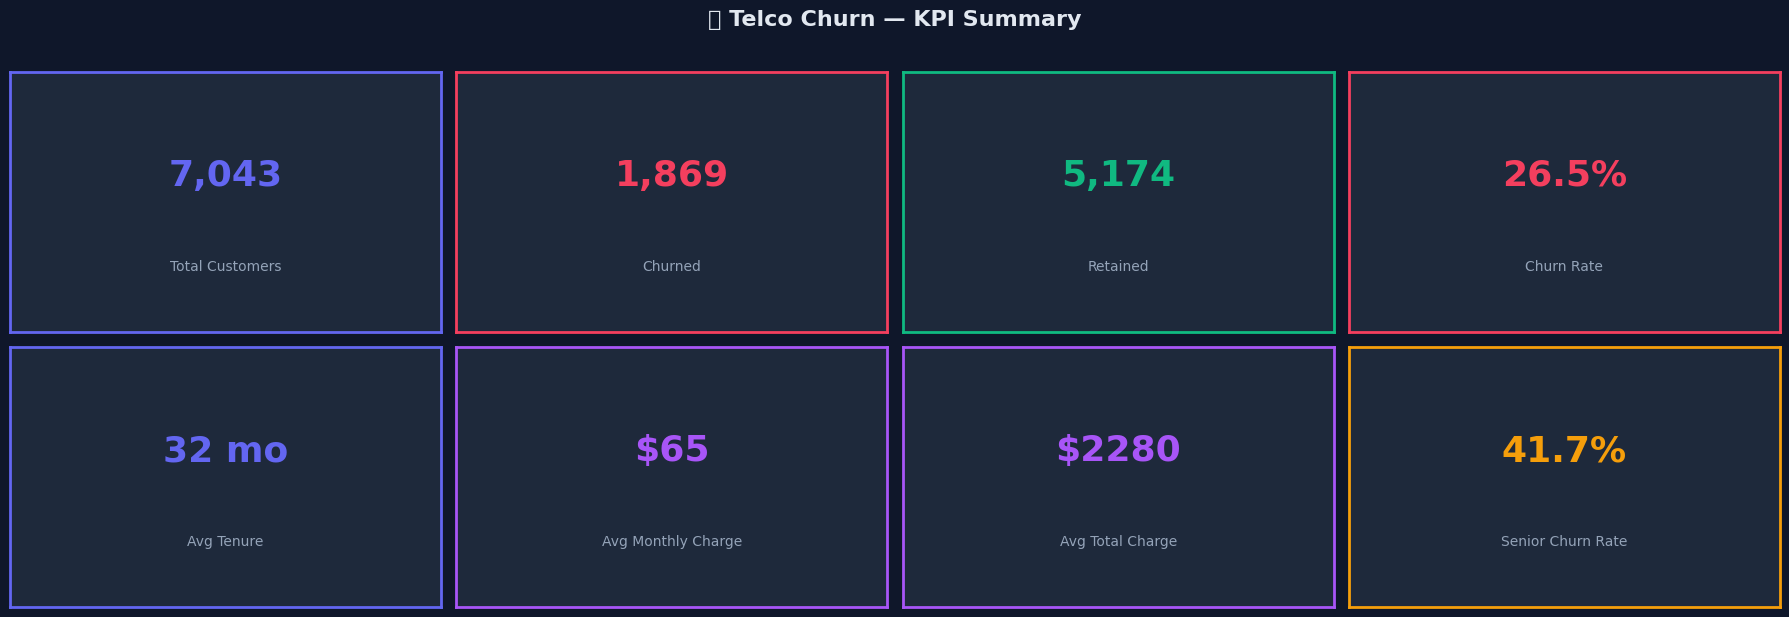

In [3]:
total      = len(df)
churned    = df['churn'].sum()
retained   = total - churned
churn_rate = churned / total * 100
avg_tenure = df['tenure'].mean()
avg_monthly = df['monthly_charges'].mean()
avg_total  = df['total_charges'].mean()
senior_churn = df[df['senior_citizen'] == 'Yes']['churn'].mean() * 100

kpis = [
    ('Total Customers',    f'{total:,}',          '#6366f1'),
    ('Churned',           f'{churned:,}',          '#f43f5e'),
    ('Retained',          f'{retained:,}',         '#10b981'),
    ('Churn Rate',        f'{churn_rate:.1f}%',    '#f43f5e'),
    ('Avg Tenure',        f'{avg_tenure:.0f} mo',  '#6366f1'),
    ('Avg Monthly Charge',f'${avg_monthly:.0f}',   '#a855f7'),
    ('Avg Total Charge',  f'${avg_total:.0f}',     '#a855f7'),
    ('Senior Churn Rate', f'{senior_churn:.1f}%',  '#f59e0b'),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
fig.suptitle('📊 Telco Churn — KPI Summary', fontsize=16, fontweight='bold', color=TEXT_COLOR, y=1.02)
axes = axes.flatten()

for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor('#1e293b')
    ax.text(0.5, 0.6, value,  ha='center', va='center', fontsize=26, fontweight='bold', color=color,   transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=10, color='#94a3b8', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2)

plt.tight_layout()
save('00_kpi_summary')

## 4️⃣ Churn Distribution

  💾 Saved → ../reports/figures/01_churn_distribution.png


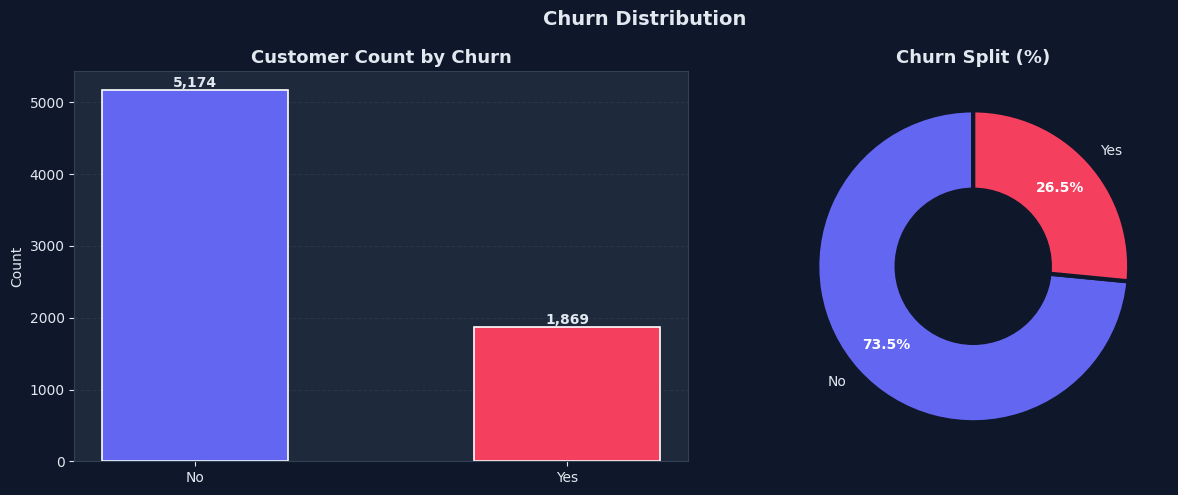

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Churn Distribution', fontsize=14, fontweight='bold')

counts = df['churn_label'].value_counts()
colors = ['#6366f1', '#f43f5e']

# Bar
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_title('Customer Count by Churn')
axes[0].set_ylabel('Count')
axes[0].yaxis.grid(True); axes[0].set_axisbelow(True)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{int(bar.get_height()):,}', ha='center', fontweight='bold', color=TEXT_COLOR)

# Donut
wedges, texts, autotexts = axes[1].pie(
    counts, labels=counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops={'edgecolor': BG_COLOR, 'linewidth': 3},
    pctdistance=0.75
)
for t in autotexts: t.set_fontweight('bold'); t.set_color('white')
# Donut hole
centre = plt.Circle((0,0), 0.5, color=BG_COLOR)
axes[1].add_patch(centre)
axes[1].set_title('Churn Split (%)')

plt.tight_layout()
save('01_churn_distribution')

## 5️⃣ Demographics Analysis

  💾 Saved → ../reports/figures/02_demographics_churn.png


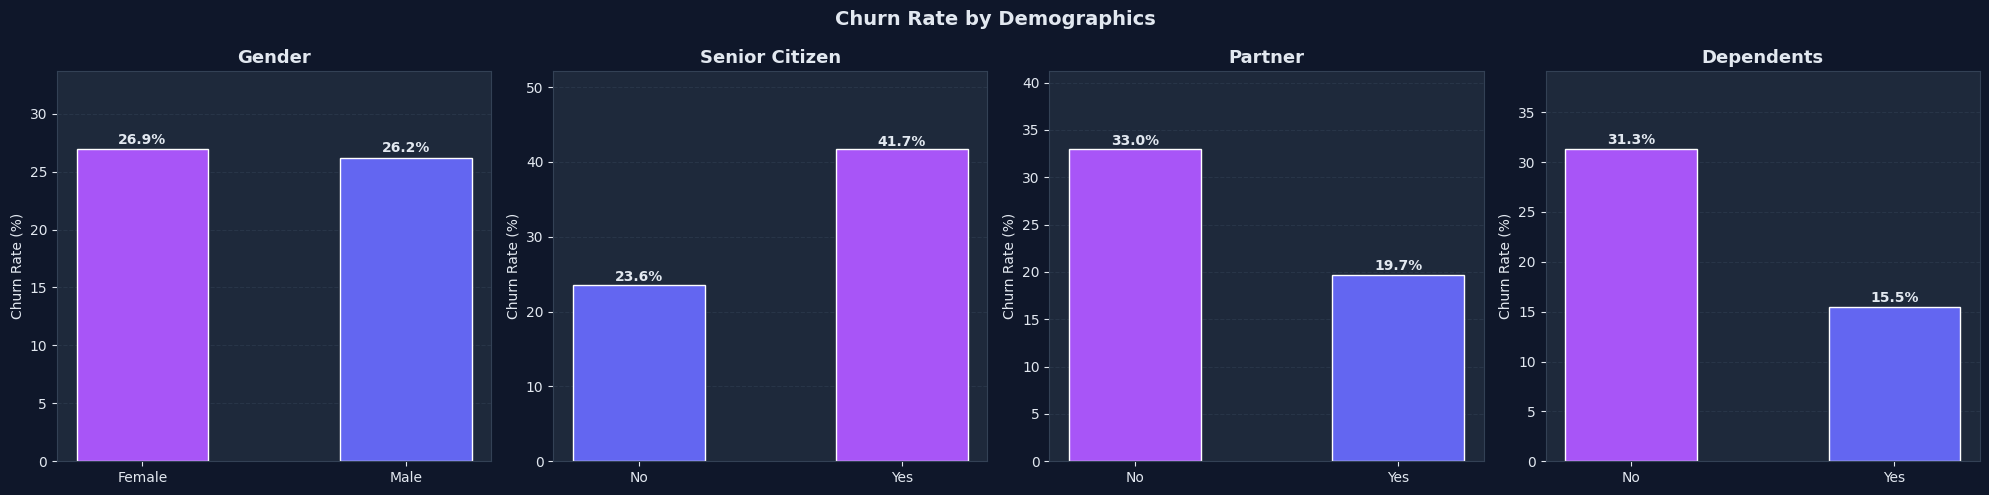

In [5]:
demo_cols = ['gender', 'senior_citizen', 'partner', 'dependents']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Churn Rate by Demographics', fontsize=14, fontweight='bold')

for ax, col in zip(axes, demo_cols):
    churn_rates = df.groupby(col)['churn'].mean() * 100
    bar_colors = [ACCENT if v == churn_rates.max() else '#6366f1' for v in churn_rates]
    bars = ax.bar(churn_rates.index, churn_rates.values, color=bar_colors,
                  edgecolor='white', linewidth=1, width=0.5)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_ylabel('Churn Rate (%)')
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    ax.set_ylim(0, churn_rates.max() * 1.25)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
save('02_demographics_churn')

## 6️⃣ Contract & Account Analysis

  💾 Saved → ../reports/figures/03_contract_account_churn.png


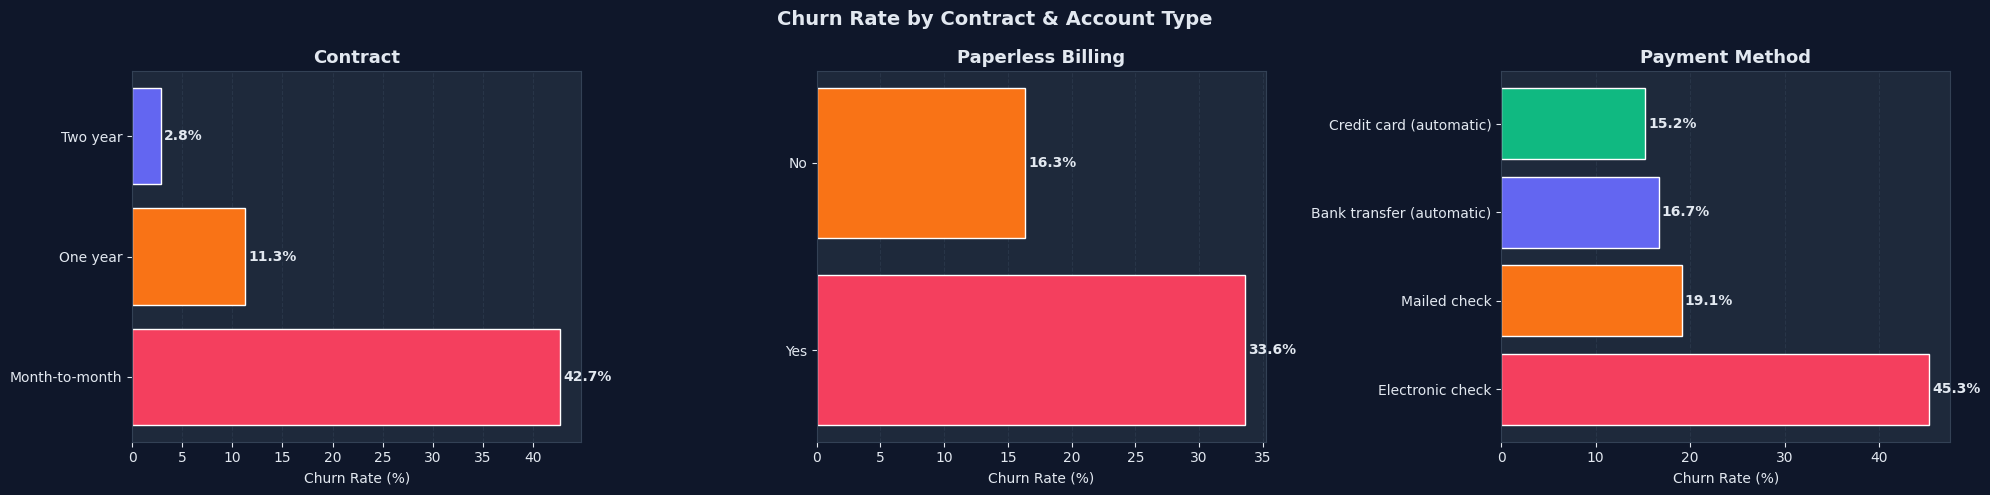

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('Churn Rate by Contract & Account Type', fontsize=14, fontweight='bold')

account_cols = ['contract', 'paperless_billing', 'payment_method']

for ax, col in zip(axes, account_cols):
    churn_rates = df.groupby(col)['churn'].mean().sort_values(ascending=False) * 100
    bar_colors = [f'#{hex(int(255 - i*50))[2:].zfill(2)}6366f1'[:7] for i in range(len(churn_rates))]
    bar_colors = ['#f43f5e', '#f97316', '#6366f1'][:len(churn_rates)] if len(churn_rates) == 3 else \
                 ['#f43f5e', '#f97316', '#6366f1', '#10b981'][:len(churn_rates)]

    bars = ax.barh(churn_rates.index, churn_rates.values,
                   color=bar_colors, edgecolor='white', linewidth=1)
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Churn Rate (%)')
    ax.xaxis.grid(True); ax.set_axisbelow(True)
    for bar in bars:
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{bar.get_width():.1f}%', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
save('03_contract_account_churn')

## 7️⃣ Internet & Services Analysis

  💾 Saved → ../reports/figures/04_services_churn.png


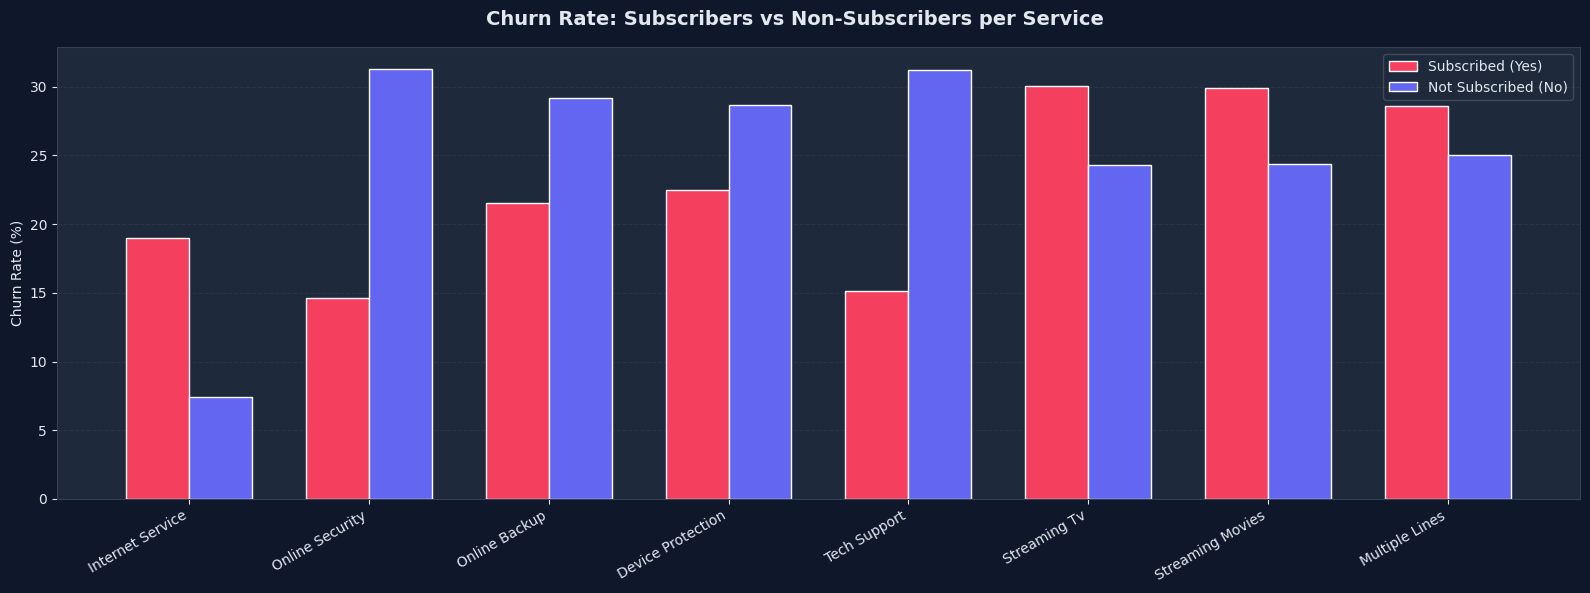

In [7]:
service_cols = ['internet_service', 'online_security', 'online_backup',
                'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'multiple_lines']

churn_by_service = {}
for col in service_cols:
    rate = df.groupby(col)['churn'].mean() * 100
    churn_by_service[col] = rate

# Churn rate for 'Yes' subscribers vs 'No'
yes_rates = [df[df[col]=='Yes']['churn'].mean()*100 if 'Yes' in df[col].unique()
             else df[df[col]==df[col].unique()[0]]['churn'].mean()*100
             for col in service_cols]
no_rates  = [df[df[col]=='No']['churn'].mean()*100 if 'No' in df[col].unique()
             else 0 for col in service_cols]

labels = [c.replace('_', ' ').title() for c in service_cols]
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('Churn Rate: Subscribers vs Non-Subscribers per Service', fontsize=14, fontweight='bold')

b1 = ax.bar(x - w/2, yes_rates, w, label='Subscribed (Yes)', color='#f43f5e', edgecolor='white')
b2 = ax.bar(x + w/2, no_rates,  w, label='Not Subscribed (No)', color='#6366f1', edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_ylabel('Churn Rate (%)')
ax.yaxis.grid(True); ax.set_axisbelow(True)
ax.legend(framealpha=0.2)

plt.tight_layout()
save('04_services_churn')

  💾 Saved → ../reports/figures/05_internet_service_churn.png


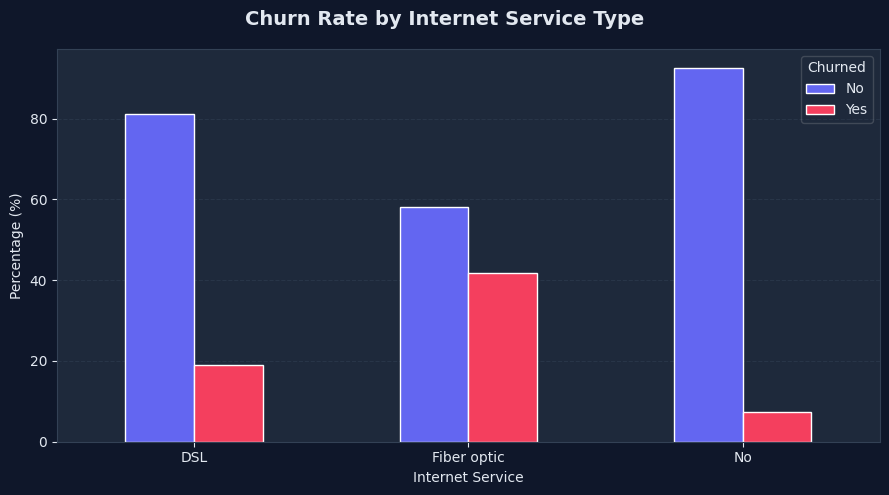

In [8]:
# Internet Service type breakdown
fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Churn Rate by Internet Service Type', fontsize=14, fontweight='bold')

ct = pd.crosstab(df['internet_service'], df['churn_label'], normalize='index') * 100
ct.plot(kind='bar', ax=ax, color=['#6366f1', '#f43f5e'], edgecolor='white', linewidth=1, rot=0)
ax.set_xlabel('Internet Service')
ax.set_ylabel('Percentage (%)')
ax.yaxis.grid(True); ax.set_axisbelow(True)
ax.legend(title='Churned', labels=['No', 'Yes'], framealpha=0.2)

plt.tight_layout()
save('05_internet_service_churn')

## 8️⃣ Charges Analysis

  💾 Saved → ../reports/figures/06_charges_distribution.png


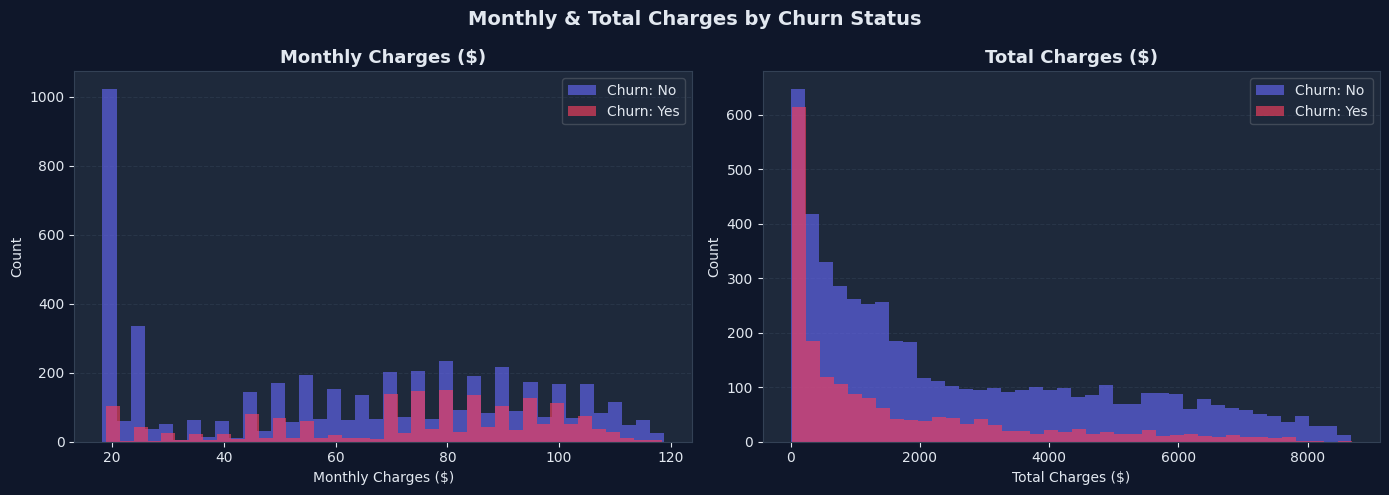

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Monthly & Total Charges by Churn Status', fontsize=14, fontweight='bold')

for ax, col, label in zip(axes, ['monthly_charges', 'total_charges'],
                                  ['Monthly Charges ($)', 'Total Charges ($)']):
    for churn_val, color in [('No', '#6366f1'), ('Yes', '#f43f5e')]:
        subset = df[df['churn_label'] == churn_val][col]
        ax.hist(subset, bins=40, alpha=0.65, color=color, label=f'Churn: {churn_val}',
                edgecolor='none')
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.yaxis.grid(True); ax.set_axisbelow(True)
    ax.legend(framealpha=0.2)

plt.tight_layout()
save('06_charges_distribution')

  💾 Saved → ../reports/figures/07_charges_boxplot.png


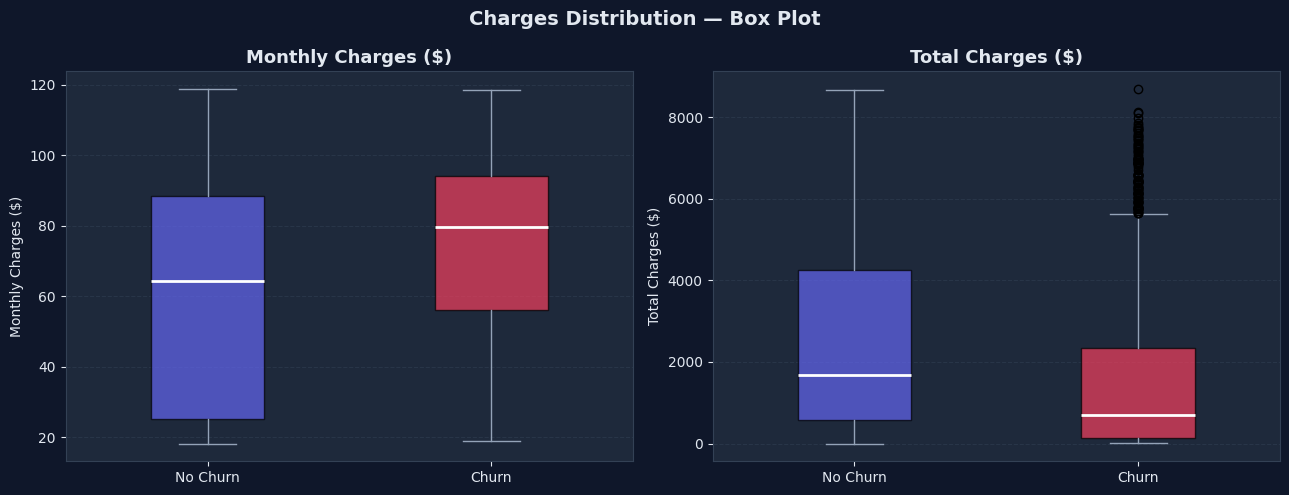

In [10]:
# Box plots
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Charges Distribution — Box Plot', fontsize=14, fontweight='bold')

for ax, col, label in zip(axes, ['monthly_charges', 'total_charges'],
                                  ['Monthly Charges ($)', 'Total Charges ($)']):
    groups = [df[df['churn_label']=='No'][col], df[df['churn_label']=='Yes'][col]]
    bp = ax.boxplot(groups, labels=['No Churn', 'Churn'],
                    patch_artist=True, widths=0.4,
                    medianprops=dict(color='white', linewidth=2))
    for patch, color in zip(bp['boxes'], ['#6366f1', '#f43f5e']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    for whisker in bp['whiskers']: whisker.set_color('#94a3b8')
    for cap in bp['caps']:         cap.set_color('#94a3b8')
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.yaxis.grid(True); ax.set_axisbelow(True)

plt.tight_layout()
save('07_charges_boxplot')

## 9️⃣ Tenure Analysis

  💾 Saved → ../reports/figures/08_tenure_analysis.png


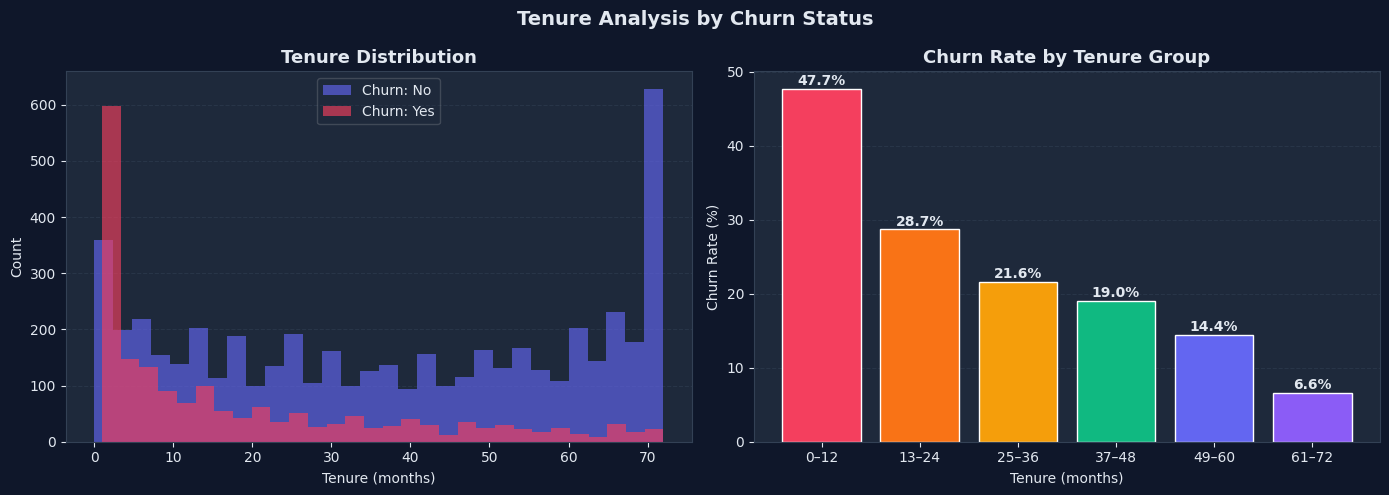

In [11]:
# Tenure histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Tenure Analysis by Churn Status', fontsize=14, fontweight='bold')

# Histogram overlay
for churn_val, color in [('No', '#6366f1'), ('Yes', '#f43f5e')]:
    subset = df[df['churn_label'] == churn_val]['tenure']
    axes[0].hist(subset, bins=30, alpha=0.65, color=color, label=f'Churn: {churn_val}', edgecolor='none')
axes[0].set_title('Tenure Distribution')
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Count')
axes[0].yaxis.grid(True); axes[0].set_axisbelow(True)
axes[0].legend(framealpha=0.2)

# Churn rate by tenure bucket
df['tenure_group'] = pd.cut(df['tenure'],
                             bins=[0, 12, 24, 36, 48, 60, 72],
                             labels=['0–12', '13–24', '25–36', '37–48', '49–60', '61–72'])
tenure_churn = df.groupby('tenure_group', observed=True)['churn'].mean() * 100

colors_grad = ['#f43f5e','#f97316','#f59e0b','#10b981','#6366f1','#8b5cf6']
axes[1].bar(tenure_churn.index, tenure_churn.values,
            color=colors_grad, edgecolor='white', linewidth=1)
axes[1].set_title('Churn Rate by Tenure Group')
axes[1].set_xlabel('Tenure (months)')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].yaxis.grid(True); axes[1].set_axisbelow(True)
for i, v in enumerate(tenure_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
save('08_tenure_analysis')

## 🔟 Correlation Heatmap

  💾 Saved → ../reports/figures/09_correlation.png


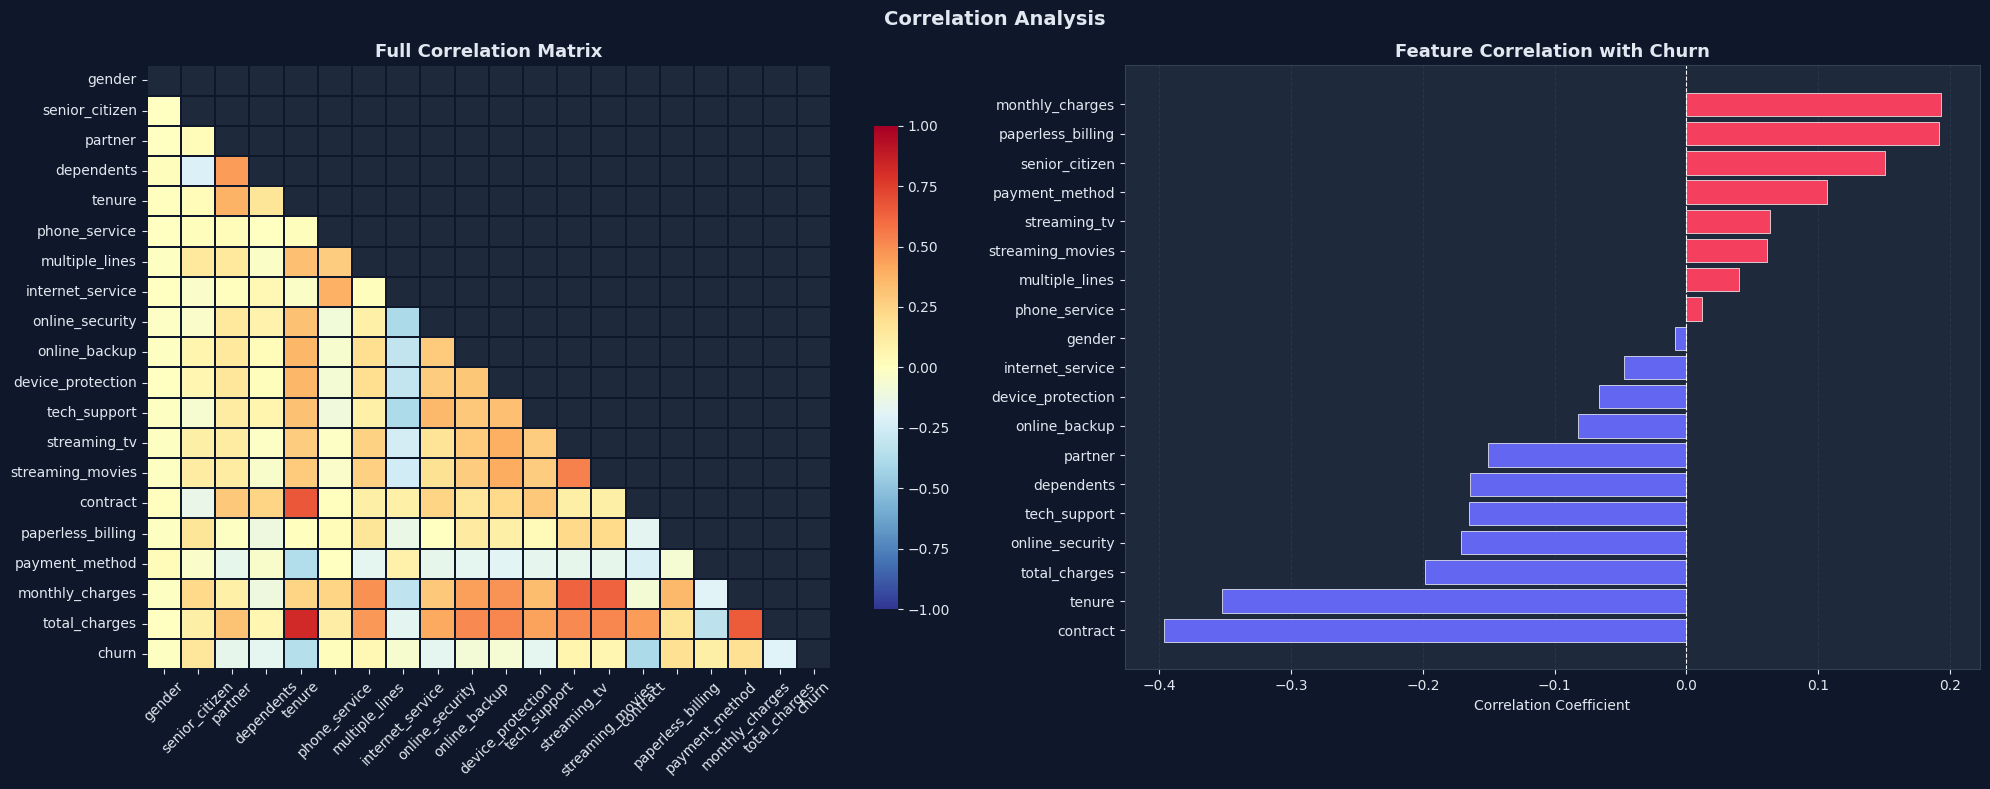

In [12]:
# Encode categoricals for correlation
from sklearn.preprocessing import LabelEncoder

df_encoded = df.drop(columns=['customer_id', 'churn_label', 'tenure_group']).copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes('object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

corr = df_encoded.corr()
churn_corr = corr['churn'].drop('churn').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

# Full heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0],
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            annot=False, linewidths=0.3, linecolor='#0f172a',
            cbar_kws={'shrink': 0.8})
axes[0].set_title('Full Correlation Matrix')
axes[0].tick_params(axis='x', rotation=45)

# Churn correlation bar chart
bar_colors = ['#f43f5e' if v > 0 else '#6366f1' for v in churn_corr]
axes[1].barh(churn_corr.index, churn_corr.values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set_title('Feature Correlation with Churn')
axes[1].set_xlabel('Correlation Coefficient')
axes[1].xaxis.grid(True); axes[1].set_axisbelow(True)

plt.tight_layout()
save('09_correlation')

## 1️⃣1️⃣ Key Takeaways

In [13]:
print('=' * 60)
print('       📋 EDA KEY TAKEAWAYS')
print('=' * 60)

# Contract type
contract_churn = df.groupby('contract')['churn'].mean() * 100
print(f'\n📄 CONTRACT TYPE:')
for k, v in contract_churn.items(): print(f'   {k:25s}: {v:.1f}% churn')

# Payment method
payment_churn = df.groupby('payment_method')['churn'].mean().sort_values(ascending=False) * 100
print(f'\n💳 PAYMENT METHOD:')
for k, v in payment_churn.items(): print(f'   {k:30s}: {v:.1f}% churn')

# Internet service
internet_churn = df.groupby('internet_service')['churn'].mean().sort_values(ascending=False) * 100
print(f'\n🌐 INTERNET SERVICE:')
for k, v in internet_churn.items(): print(f'   {k:20s}: {v:.1f}% churn')

# Tenure groups
print(f'\n⏱️  TENURE GROUPS (churn rate):')
tenure_churn = df.groupby('tenure_group', observed=True)['churn'].mean().sort_values(ascending=False) * 100
for k, v in tenure_churn.items(): print(f'   {str(k):10s} months: {v:.1f}%')

# Charges avg
print(f'\n💰 AVG MONTHLY CHARGES:')
for churn_val in ['No', 'Yes']:
    avg = df[df['churn_label']==churn_val]['monthly_charges'].mean()
    print(f'   Churn = {churn_val}: ${avg:.2f}')

print('\n' + '=' * 60)
print(f'✅ All figures saved to: {FIG_DIR}/')

       📋 EDA KEY TAKEAWAYS

📄 CONTRACT TYPE:
   Month-to-month           : 42.7% churn
   One year                 : 11.3% churn
   Two year                 : 2.8% churn

💳 PAYMENT METHOD:
   Electronic check              : 45.3% churn
   Mailed check                  : 19.1% churn
   Bank transfer (automatic)     : 16.7% churn
   Credit card (automatic)       : 15.2% churn

🌐 INTERNET SERVICE:
   Fiber optic         : 41.9% churn
   DSL                 : 19.0% churn
   No                  : 7.4% churn

⏱️  TENURE GROUPS (churn rate):
   0–12       months: 47.7%
   13–24      months: 28.7%
   25–36      months: 21.6%
   37–48      months: 19.0%
   49–60      months: 14.4%
   61–72      months: 6.6%

💰 AVG MONTHLY CHARGES:
   Churn = No: $61.27
   Churn = Yes: $74.44

✅ All figures saved to: ../reports/figures/


---

## 📤 Exported Figures (for Power BI / Tableau)

| File | Chart |
|---|---|
| `00_kpi_summary.png` | KPI dashboard tiles |
| `01_churn_distribution.png` | Bar + Donut churn split |
| `02_demographics_churn.png` | Churn by gender, senior, partner, dependents |
| `03_contract_account_churn.png` | Churn by contract, billing, payment |
| `04_services_churn.png` | Grouped bar: subscriber vs non-subscriber churn |
| `05_internet_service_churn.png` | Stacked bar: internet service type |
| `06_charges_distribution.png` | Histogram overlay: monthly & total charges |
| `07_charges_boxplot.png` | Box plots: charges by churn |
| `08_tenure_analysis.png` | Tenure histogram + churn rate by tenure bucket |
| `09_correlation.png` | Heatmap + feature correlations with churn |

> 📂 All saved in `reports/figures/`